# 03 — Descriptive Analytics
**Capstone Project — Group 5 — DAMO-699, Summer 2026**

Answers RQ1 ("what was reported?") using the cleaned, feature-engineered dataset from
`02_data_cleaning.ipynb`. Every rate is shown next to its underlying count, per the charter's
instruction that a high damage count can just reflect high exposure, not a high damage rate.


> **Google Colab version.** Only the project-root cell below differs from the VS Code / local version: it mounts Google Drive and points `PROJECT_ROOT` at `My Drive/Colab Notebooks/CAPSTONE` instead of `D:\CAPSTONE PROJECT`. Every other cell, path, and analytical step is identical - `database/`, `Input_Files/`, and `Outputs_Files/` must exist under that Drive folder with the same layout as the local project.


In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 120)
plt.rcParams["figure.dpi"] = 110

from google.colab import drive
drive.mount('/content/drive')

# Colab equivalent of the local D:\CAPSTONE PROJECT root - same folder
# structure (database / Input_Files / Outputs_Files), just mounted from
# Google Drive instead of the Windows filesystem. Update this one line if
# your Drive folder name or location differs.
PROJECT_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/CAPSTONE")
PROCESSED_DIR = PROJECT_ROOT / "database" / "processed"
DICT_DIR = PROJECT_ROOT / "Outputs_Files" / "dictionaries"
OUT_DIR = PROJECT_ROOT / "Outputs_Files" / "03"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CLEAN_PATH = PROCESSED_DIR / "faa_strikes_clean_full.csv"
assert CLEAN_PATH.exists(), f"{CLEAN_PATH} not found - run 02_data_cleaning.ipynb first."

df = pd.read_csv(CLEAN_PATH, low_memory=False)
with open(DICT_DIR / "feature_lists.json") as f:
    feature_lists = json.load(f)

print(f"Loaded cleaned dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print("Damage rate:", round(df["INDICATED_DAMAGE"].mean() * 100, 2), "%")

Mounted at /content/drive
Loaded cleaned dataset: 319,107 rows x 110 columns
Damage rate: 6.55 %


**What it does:** Loads the full cleaned dataset (kept complete on purpose here, since
descriptive analytics can legitimately show cost/injury numbers even though those fields stay
excluded from prediction) and the shared feature lists from `02`.

**Why it matters:** every chart in this notebook builds on the same cleaned, deduplicated,
temporally-scoped data instead of re-deriving cleaning logic — keeping one source of truth
across notebooks is what the review meant by requiring a real cleaned dataset in the first
place.

**Result review:** row count should be a little under 348,146 (after dropping the seven
duplicate-species records and any rows outside 1990–2024), with the damage rate close to the
6.3% figure confirmed in `01`.


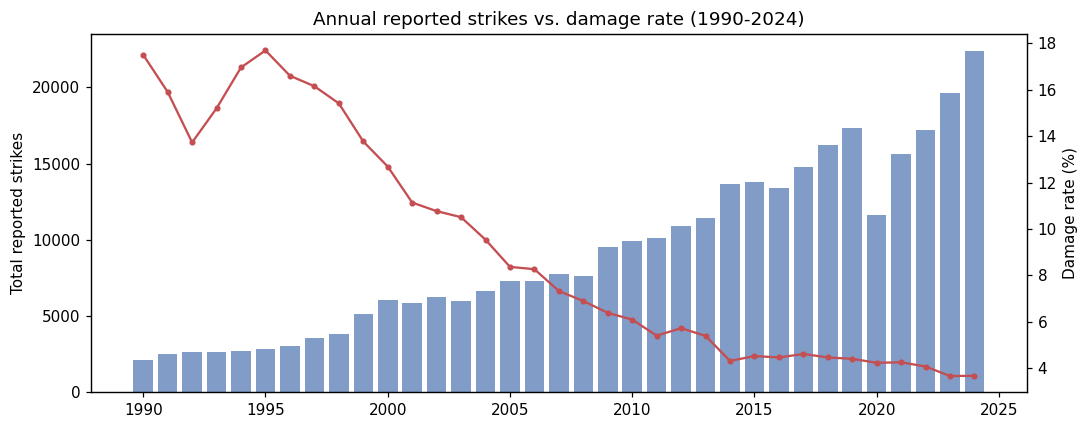

,total_strikes,damaging_strikes,damage_rate_pct
INCIDENT_YEAR,,,
2015,13777,624,4.53
2016,13378,598,4.47
2017,14756,681,4.62
2018,16206,725,4.47
2019,17348,765,4.41
2020,11625,493,4.24
2021,15641,667,4.26
2022,17223,702,4.08
2023,19625,721,3.67


In [2]:
annual = df.groupby("INCIDENT_YEAR").agg(
    total_strikes=("INDEX_NR", "count"),
    damaging_strikes=("INDICATED_DAMAGE", "sum"),
).assign(damage_rate_pct=lambda x: (x["damaging_strikes"] / x["total_strikes"] * 100).round(2))
annual.to_csv(OUT_DIR / "03_annual_strike_volume_and_damage_rate.csv")

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.bar(annual.index, annual["total_strikes"], color="#4C72B0", alpha=0.7, label="Total strikes")
ax1.set_ylabel("Total reported strikes")
ax2 = ax1.twinx()
ax2.plot(annual.index, annual["damage_rate_pct"], color="#C44E52", marker="o", markersize=3, label="Damage rate %")
ax2.set_ylabel("Damage rate (%)")
ax1.set_title("Annual reported strikes vs. damage rate (1990-2024)")
fig.tight_layout()
fig.savefig(OUT_DIR / "03_annual_volume_vs_damage_rate.png")
plt.show()

annual.tail(10)

**What it does:** Counts total reported strikes and the damage rate per year, and plots both
on one chart (bars for volume, a line for the rate) so growth in reporting isn't confused with
growth in risk.

**Why it matters:** annual strike counts have grown a lot over the database's history — that
reflects better reporting compliance and more air traffic, not necessarily wildlife getting
more dangerous. Showing the damage *rate* next to the raw count is exactly the counts-vs-rates
distinction the charter requires.

**Result review:** expect total strikes to trend upward over the decades (reporting
compliance improved after FAA outreach in the 2000s) while the damage rate stays much flatter
— that pattern would confirm the volume increase is a reporting artifact, not a real safety
trend.


In [3]:
seasonal = df.groupby("SEASON").agg(
    total_strikes=("INDEX_NR", "count"),
    damage_rate_pct=("INDICATED_DAMAGE", lambda s: round(s.mean() * 100, 2)),
).reindex(["Winter", "Spring", "Summer", "Fall"])
seasonal.to_csv(OUT_DIR / "03_seasonal_pattern.csv")
seasonal

,total_strikes,damage_rate_pct
SEASON,,
Winter,32443,10.97
Spring,68557,7.65
Summer,112062,4.16
Fall,106045,7.01


**What it does:** Groups strikes by season and shows both the count and the damage rate for
each.

**Why it matters:** bird migration is strongly seasonal, so strike volume should move a lot
across the year — this is one of the "monthly and seasonal patterns" the charter asks for and
also feeds directly into the `SEASON` predictor used later in modelling.

**Result review:** expect Fall to have the highest strike volume (peak migration), but check
whether the damage *rate* actually follows the same pattern — a season with more strikes
doesn't automatically have a higher per-strike damage rate.


In [4]:
region_state = df.groupby("FAAREGION").agg(
    total_strikes=("INDEX_NR", "count"),
    damage_rate_pct=("INDICATED_DAMAGE", lambda s: round(s.mean() * 100, 2)),
).sort_values("total_strikes", ascending=False)
region_state.to_csv(OUT_DIR / "03_by_faa_region.csv")

top_airports = df.groupby("AIRPORT_ID").agg(
    total_strikes=("INDEX_NR", "count"),
    damage_rate_pct=("INDICATED_DAMAGE", lambda s: round(s.mean() * 100, 2)),
).sort_values("total_strikes", ascending=False).head(15)
top_airports.to_csv(OUT_DIR / "03_top15_airports.csv")

print("By FAA region:")
print(region_state)
print("\nTop 15 airports by strike volume:")
print(top_airports)

By FAA region:
           total_strikes  damage_rate_pct
FAAREGION                                
ASO                60200             5.88
AEA                43555             6.71
AGL                43425             5.62
ASW                37244             4.84
AWP                34022             6.48
ANM                29340             5.39
ACE                12986             6.30
ANE                10312             6.13
FGN                 5340             8.69
AAL                 1580            13.23

Top 15 airports by strike volume:
            total_strikes  damage_rate_pct
AIRPORT_ID                                
ZZZZ                41026            10.41
KDEN                10690             2.21
KDFW                 8414             3.15
KORD                 6864             3.86
KJFK                 6372             4.99
KMEM                 5203             3.75
KSLC                 4125             8.80
KATL                 3987             3.54
KDTW            

**What it does:** Breaks strike counts and damage rates down by FAA region, and separately
ranks the 15 airports with the most reported strikes.

**Why it matters:** this is the geographic view the descriptive-analytics section requires,
and the region-level table is also the reality check for whether `FAAREGION` will actually
add predictive signal in `05_damage_modelling.ipynb`.

**Result review:** expect a handful of high-traffic regions to dominate the strike count.
Watch whether damage rate varies meaningfully by region — a region with high volume but a
similar damage rate to everywhere else suggests region mostly reflects traffic exposure, not
a real geographic risk difference.


In [5]:
wildlife = df.groupby("WILDLIFE_SIZE_GROUP").agg(
    total_strikes=("INDEX_NR", "count"),
    damage_rate_pct=("INDICATED_DAMAGE", lambda s: round(s.mean() * 100, 2)),
)
wildlife.to_csv(OUT_DIR / "03_by_wildlife_size.csv")

num_struck_summary = df["NUM_STRUCK"].describe()

print("By wildlife size:")
print(wildlife)
print("\nNUM_STRUCK summary stats:")
print(num_struck_summary)

By wildlife size:
                     total_strikes  damage_rate_pct
WILDLIFE_SIZE_GROUP                                
Large                        19601            32.96
Medium                       71310            12.59
Small                       196704             2.04
Unknown                      31492             4.63

NUM_STRUCK summary stats:
count    318426.000000
mean          1.818261
std           4.312853
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         100.000000
Name: NUM_STRUCK, dtype: float64


**What it does:** Shows strike count and damage rate by wildlife size category, and
summarizes how many animals were struck per incident.

**Why it matters:** this is one of the project's central hypotheses (H3 in the proposal) —
larger wildlife and more animals struck should associate with a higher damage rate. This
table is the first direct look at that relationship, ahead of the formal chi-square test in
`04_diagnostic_analytics.ipynb`.

**Result review:** expect the damage rate to climb clearly from Small to Large wildlife —
that's the expected direction the hypothesis predicts. If it doesn't, that's worth flagging
rather than glossing over, since it would mean H3 needs a closer look with confounders
controlled (which is exactly what `04` does with multivariable logistic regression).


In [6]:
aircraft_summary = df.groupby("AC_MASS_GROUP").agg(
    total_strikes=("INDEX_NR", "count"),
    damage_rate_pct=("INDICATED_DAMAGE", lambda s: round(s.mean() * 100, 2)),
)
engine_summary = df.groupby("TYPE_ENG").agg(
    total_strikes=("INDEX_NR", "count"),
    damage_rate_pct=("INDICATED_DAMAGE", lambda s: round(s.mean() * 100, 2)),
).sort_values("total_strikes", ascending=False)

aircraft_summary.to_csv(OUT_DIR / "03_by_aircraft_mass.csv")
engine_summary.to_csv(OUT_DIR / "03_by_engine_type.csv")

print("By aircraft mass group:")
print(aircraft_summary)
print("\nBy engine type:")
print(engine_summary)

By aircraft mass group:
               total_strikes  damage_rate_pct
AC_MASS_GROUP                                
Heavy                 164180             6.31
Light                  27849            24.43
Medium                 36133             9.89
Unknown                90945             0.19

By engine type:
          total_strikes  damage_rate_pct
TYPE_ENG                                
D                192284             6.89
C                 15364            14.62
A                 15167            27.38
F                  4613            18.25
B                   413            24.70
E                     5            60.00
Y                     3             0.00


**What it does:** Shows damage rate by aircraft mass category and by engine type.

**Why it matters:** aircraft characteristics are core scenario-input predictors. This table is
a sanity check before modelling — if there's no visible relationship at all here, that's worth
knowing early rather than after training a model that quietly ignores these features.

**Result review:** lighter aircraft (Light/Medium mass group) typically show a higher per
strike damage rate than Heavy commercial jets, since larger aircraft structures tolerate a
bird strike better. If the data agrees, that supports keeping `AC_MASS_GROUP` as a strong
predictor.


In [7]:
phase_summary = df.groupby("PHASE_OF_FLIGHT").agg(
    total_strikes=("INDEX_NR", "count"),
    damage_rate_pct=("INDICATED_DAMAGE", lambda s: round(s.mean() * 100, 2)),
).sort_values("total_strikes", ascending=False)
phase_summary.to_csv(OUT_DIR / "03_by_phase_of_flight.csv")

height_speed_by_damage = df.groupby("INDICATED_DAMAGE")[["HEIGHT", "SPEED"]].median()
height_speed_by_damage.to_csv(OUT_DIR / "03_height_speed_median_by_damage.csv")

warned_summary = df.groupby("WARNED").agg(
    total_strikes=("INDEX_NR", "count"),
    damage_rate_pct=("INDICATED_DAMAGE", lambda s: round(s.mean() * 100, 2)),
)
warned_summary.to_csv(OUT_DIR / "03_by_warned_status.csv")

print("By phase of flight:")
print(phase_summary)
print("\nMedian height/speed by damage outcome:")
print(height_speed_by_damage)
print("\nBy warning status:")
print(warned_summary)

By phase of flight:
                 total_strikes  damage_rate_pct
PHASE_OF_FLIGHT                                
Unknown                 124521             2.01
Approach                 82366             8.71
Landing Roll             35183             5.70
Take-off Run             32638             7.58
Climb                    29077            14.74
En Route                  5871            30.22
Departure                 3546             3.27
Descent                   2707            14.85
Local                     1404             6.48
Arrival                    927             4.64
Taxi                       753             5.44
Parked                     114             3.51

Median height/speed by damage outcome:
                  HEIGHT  SPEED
INDICATED_DAMAGE               
0                   25.0  140.0
1                  400.0  135.0

By warning status:
         total_strikes  damage_rate_pct
WARNED                                 
No               64521            11.75


**What it does:** Shows damage rate by flight phase and warning status, and compares median
height/speed between damaging and non-damaging strikes.

**Why it matters:** these are core flight-context predictors. Take-off and landing phases
typically carry the most strike volume simply because that's when aircraft fly at
bird-altitude — this table shows whether they also carry a different damage rate, not just
more strikes.

**Result review:** expect Take-off Run and Approach/Landing to dominate both count and a
non-trivial damage rate. If warned flights show a lower damage rate than unwarned ones,
that's a plausible operational-avoidance effect worth mentioning in the report, with the
caveat that this is an association, not a causal claim yet.


In [8]:
severity_dist = df.loc[df["INDICATED_DAMAGE"] == 1, "DAMAGE_LEVEL"].value_counts(dropna=False)
severity_dist_pct = (df.loc[df["INDICATED_DAMAGE"] == 1, "DAMAGE_LEVEL"].value_counts(normalize=True, dropna=False) * 100).round(2)
severity_table = pd.DataFrame({"count": severity_dist, "pct_of_damaged": severity_dist_pct})
severity_table.to_csv(OUT_DIR / "03_severity_distribution.csv")

dam_cols = [c for c in df.columns if c.startswith("DAM_")]
component_dist = df[dam_cols].sum().sort_values(ascending=False)
component_dist_pct = (df[dam_cols].mean() * 100).round(3).sort_values(ascending=False)
component_table = pd.DataFrame({"positive_count": component_dist, "pct_of_all_strikes": component_dist_pct})
component_table.to_csv(OUT_DIR / "03_component_damage_distribution.csv")

print("Severity distribution among damaged strikes:")
print(severity_table)
print("\nComponent damage distribution (all strikes):")
print(component_table.head(10))

Severity distribution among damaged strikes:
              count  pct_of_damaged
DAMAGE_LEVEL                       
M              8657           41.41
M?             7818           37.39
S              4344           20.78
D                89            0.43

Component damage distribution (all strikes):
              positive_count  pct_of_all_strikes
DAM_WING_ROT            6296               1.973
DAM_ENG1                3085               0.967
DAM_ENG2                2602               0.815
DAM_OTHER               2455               0.769
DAM_RAD                 2105               0.660
DAM_NOSE                1763               0.552
DAM_WINDSHLD            1468               0.460
DAM_LG                  1308               0.410
DAM_FUSE                1209               0.379
DAM_TAIL                1052               0.330


**What it does:** Shows the severity breakdown among damaged strikes and ranks every
component-damage field by how often it occurs.

**Why it matters:** this is the descriptive companion to the severity and component analysis
started in `01` — it's what will eventually go into the report as the plain "what happened"
picture, before any model tries to predict it.

**Result review:** severity should be dominated by Minor damage, with Substantial a smaller
share and Destroyed the rarest. Component damage should be led by windshield, nose, and
engine — consistent with what actually gets hit at flight altitude and speed.


In [9]:
missingness_by_year = df.groupby("INCIDENT_YEAR")[["HEIGHT", "SPEED", "SKY", "TIME_OF_DAY"]].apply(
    lambda g: g.isna().mean() * 100
).round(1)
missingness_by_region = df.groupby("FAAREGION")[["HEIGHT", "SPEED", "SKY"]].apply(
    lambda g: g.isna().mean() * 100
).round(1)
missingness_by_damage = df.groupby("INDICATED_DAMAGE")[["HEIGHT", "SPEED", "SKY"]].apply(
    lambda g: g.isna().mean() * 100
).round(1)

missingness_by_year.to_csv(OUT_DIR / "03_missingness_by_year.csv")
missingness_by_region.to_csv(OUT_DIR / "03_missingness_by_region.csv")
missingness_by_damage.to_csv(OUT_DIR / "03_missingness_by_damage.csv")

print("Missingness % by damage outcome:")
print(missingness_by_damage)

Missingness % by damage outcome:
                  HEIGHT  SPEED  SKY
INDICATED_DAMAGE                    
0                   51.3   70.1  0.0
1                   24.4   43.9  0.0


**What it does:** Reports missingness percentages for a few key fields, broken down by year,
FAA region, and damage outcome.

**Why it matters:** this closes the "missingness by variable, year, region, and damage
outcome" requirement from the charter's descriptive-analytics section, and it's the
evidence base for the reporting-completeness-bias concern the proposal raises.

**Result review:** if damaged strikes are consistently more complete than non-damaged ones
across these fields, that confirms the bias the proposal flagged, and it's the reason
`02_data_cleaning.ipynb` uses imputation and missingness-indicator flags rather than dropping
incomplete rows.


## Recommended Follow-Up Analyses

1. Formal chi-square/Cramér's V tests for wildlife size, flight phase, and aircraft mass
   against damage — `04_diagnostic_analytics.ipynb`.
2. Multivariable logistic regression to check whether these associations hold once other
   factors are controlled for.
3. A closer look at the interaction between wildlife size and aircraft mass, since the
   descriptive tables above show both moving damage rate in the expected direction
   separately.
4. Region-level damage-rate differences deserve a residual/effect-size check, not just a
   raw comparison — some of the regional gap is almost certainly traffic-mix, not location
   risk.
5. Height/speed by phase of flight, since both vary enormously between Take-off Run and
   En Route and a flat median hides that.
